# Road Traffic Accidents in Finland 2015–2024
## Weather, season and accident severity — a CRISP-DM analysis

**Course:** Datan käsittely ja koneoppiminen · **Process model:** CRISP-DM

| Phase | Section |
|---|---|
| 1 | Business Understanding |
| 2 | Data Understanding (accidents + FMI weather) |
| 3 | Data Preparation |
| 4 | Modeling |
| 5 | Evaluation |
| 6 | Deployment |

**Data sources**
- **Road traffic accidents:** Statistics Finland (Tilastokeskus) WFS service, layers `tieliikenne_2015 … tieliikenne_2024`. One row = one accident that led to injury or death, with year, month, hour, severity, type, involved vehicle groups and EPSG:3067 coordinates.
- **Weather:** Finnish Meteorological Institute (FMI) open data, daily observations from all stations in Finland.

**Folder layout expected by this notebook**
```
traffic_accidents_analysis.ipynb
datasets/
    tieliikenne_2015.csv ... tieliikenne_2024.csv
    fmi_cache/            <- created automatically (one small CSV per downloaded month)
```

## 1. Business Understanding

### 1.1 Background and objective
Road safety work needs to know **when** accident risk is high and **what makes an accident severe**. A common belief is that winter conditions (cold, snow, ice) are the main trigger of severe accidents. We test this belief with data instead of assuming it.

An important limitation shapes the whole project: the accident data contain **year and month but no exact date**. Every link between accidents and weather therefore has to be made at **monthly resolution**.

### 1.2 Research questions
- **RQ1:** Can the severity of an injury accident (fatal or serious injury vs. lighter injury) be predicted from the characteristics of the accident (accident type, road users involved, time of day)?
- **RQ2:** Do environmental and seasonal variables (monthly mean temperature, precipitation, snow depth and share of frost days from the nearest weather station) improve the prediction, and can they predict severity on their own?

### 1.3 Hypotheses
- **H1:** Months with harsher winter weather (cold, snow) have a higher share of severe accidents.
- **H2:** Adding weather variables to the accident characteristics improves the prediction of severity.

### 1.4 Success criteria
- **RQ1:** the model performs clearly better than chance, meaning ROC-AUC clearly above 0.5 and PR-AUC clearly above the base rate of severe accidents (about 14%). A model that always answers "less severe" is not a success even if its accuracy looks high, so the severe class must really be detected.
- **RQ2:** weather is considered useful if the model with weather has a higher ROC-AUC and PR-AUC than the same model without weather, evaluated on the same test accidents.

### 1.5 Constraints and assumptions
- Monthly resolution only; weather is a **national monthly aggregate** (not the weather at the accident site).
- Only accidents that led to injury or death are in the data, so we model *injury accidents*, not all collisions.
- No traffic-volume (exposure) data are available; the number of accidents depends on how much people drive.

## 2. Data Understanding


### 2.1 Setup


The project uses data from two sources. The road traffic accident data from **Statistics Finland** is provided as yearly CSV files covering the period from 2015 to 2024. The available files are loaded from the local datasets directory and combined into a single DataFrame.


The weather data is retrieved from the **Finnish Meteorological Institute (FMI) Open Data service** using the stored query. Daily observations on the weather are collected from the weather stations across the Finland. The analysis focuses on daily mean temperatures, precipitation and snow depth.

To make the data collection more efficient, the downloaded **FMI data** is stored locally under the **datasets/fmi_cache/**. If a file is already available, is it loaded from the cache instead of being downloaded again.

At this stage, **the two datasets** are loaded and examined separately. Their structures, variables, datatypes and missing values are inspected before proceeding to data preparation and integration.

In [2884]:
# 1. Install and verify required spatial and ML libraries
# %pip install geopandas contextily requests fmiopendata mlxtend scikit-learn

# 2. Import core engines
import glob
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
import datetime as dt

from fmiopendata.wfs import download_stored_query

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, roc_auc_score, average_precision_score,
                             classification_report, ConfusionMatrixDisplay, RocCurveDisplay)


from weather_api_functions import _find_value, _download_range, fetch_fmi_month, load_weather_month

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 69
DATA_DIR = "datasets"            # folder that holds tieliikenne_YYYY.csv
YEARS = list(range(2015, 2025))

### 2.2 Accident data (Statistics Finland)
All ten yearly files are loaded and stacked. Columns (identical in every file):

| Column | Meaning |
|---|---|
| `vvonn`, `kkonn` | year and month of the accident (no day) |
| `kello` | one-hour interval, format `HH.00-HH.59` |
| `vakav` | severity: 1 = fatal, 2 = injury, 3 = serious injury |
| `onntyyppi` | accident type 0–9 (same/opposite/crossing directions, pedestrian, run-off-road, other) |
| `lkmhapa … lkmmuukulk` | number of involved road users per group (cars and vans, buses and trucks, pedestrians, bicycles, mopeds, motorcycles, others) |
| `x`, `y` | location, EPSG:3067 (ETRS-TM35FIN) |

In [2885]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "tieliikenne_20*.csv")))
print("Files found:", [os.path.basename(f) for f in files])
assert len(files) == len(YEARS), "Expected one file per year 2015-2024"

df_accidents = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("\nShape (rows, columns):", df_accidents.shape)
print("\nData types:")
print(df_accidents.dtypes)
display(df_accidents.head())

Files found: ['tieliikenne_2015.csv', 'tieliikenne_2016.csv', 'tieliikenne_2017.csv', 'tieliikenne_2018.csv', 'tieliikenne_2019.csv', 'tieliikenne_2020.csv', 'tieliikenne_2021.csv', 'tieliikenne_2022.csv', 'tieliikenne_2023.csv', 'tieliikenne_2024.csv']

Shape (rows, columns): (38372, 17)

Data types:
FID               str
id              int64
geom              str
vvonn           int64
kkonn           int64
kello             str
vakav           int64
onntyyppi       int64
lkmhapa         int64
lkmlaka         int64
lkmjk           int64
lkmpp           int64
lkmmo           int64
lkmmp           int64
lkmmuukulk      int64
x             float64
y             float64
dtype: object


,FID,id,geom,vvonn,kkonn,kello,vakav,onntyyppi,lkmhapa,lkmlaka,lkmjk,lkmpp,lkmmo,lkmmp,lkmmuukulk,x,y
0,tieliikenne_2015.1,1,POINT (397544.8774 6675865.1006),2015,1,18.00-18.59,2,6,1,0,1,0,0,0,0,397544.8774,6675865.1006
1,tieliikenne_2015.2,2,POINT (382175.8528 6678657.1592),2015,1,06.00-06.59,2,6,1,0,1,0,0,0,0,382175.8528,6678657.1592
2,tieliikenne_2015.3,3,POINT (393635.8546 6677840.6594),2015,1,16.00-16.59,2,0,3,0,0,0,0,0,0,393635.8546,6677840.6594
3,tieliikenne_2015.4,4,POINT (383847.8421 6671277.6964),2015,12,12.00-12.59,2,4,1,0,0,1,0,0,0,383847.8421,6671277.6964
4,tieliikenne_2015.5,5,POINT (386309.4585 6673319.5558),2015,1,07.00-07.59,2,6,1,0,1,0,0,0,0,386309.4585,6673319.5558


In total, there are 17 columns of data in the dataset. 

In [2886]:
print("Missing values")
print(df_accidents.isna().sum()[lambda s: s > 0])
print("\nRows with missing 'kello' per year:")
print(df_accidents[df_accidents["kello"].isna()]["vvonn"].value_counts().sort_index())
print("\nDuplicate FIDs:", df_accidents["FID"].duplicated().sum())

Missing values
kello    16
dtype: int64

Rows with missing 'kello' per year:
vvonn
2017    2
2018    4
2020    3
2021    4
2022    2
2024    1
Name: count, dtype: int64

Duplicate FIDs: 0


Variable (`kello`) is the only one with missing values, with a total of 16.

In [2887]:
# Class variable codebook
SEVERITY_LABELS = {1: "fatal", 2: "injury", 3: "serious injury"}
ACCIDENT_TYPES = {
    0: "same direction (straight)",
    1: "same direction (turning)",
    2: "opposite directions (straight)",
    3: "opposite directions (turning)",
    4: "crossing directions (straight)",
    5: "crossing directions (turning)",
    6: "pedestrian (crossing)",
    7: "pedestrian (elsewhere)",
    8: "run off the road",
    9: "other",
}

counts = pd.DataFrame({
    "severity": df_accidents["vakav"].map(SEVERITY_LABELS).value_counts(),
})
counts["share_%"] = (counts["severity"] / len(df_accidents) * 100).round(1)
display(counts)

type_counts = df_accidents["onntyyppi"].map(ACCIDENT_TYPES).value_counts()
display(type_counts.to_frame("accidents"))

,severity,share_%
vakav,,
injury,32760,85.4
serious injury,3576,9.3
fatal,2036,5.3


,accidents
onntyyppi,
run off the road,10450
same direction (straight),5503
crossing directions (straight),5498
other,3276
same direction (turning),3268
opposite directions (straight),3074
crossing directions (turning),2321
pedestrian (crossing),1892
opposite directions (turning),1760


### 2.3 Accidents over time
Two patterns matter for modeling: a **strong long-term decline** and a **seasonal cycle**.

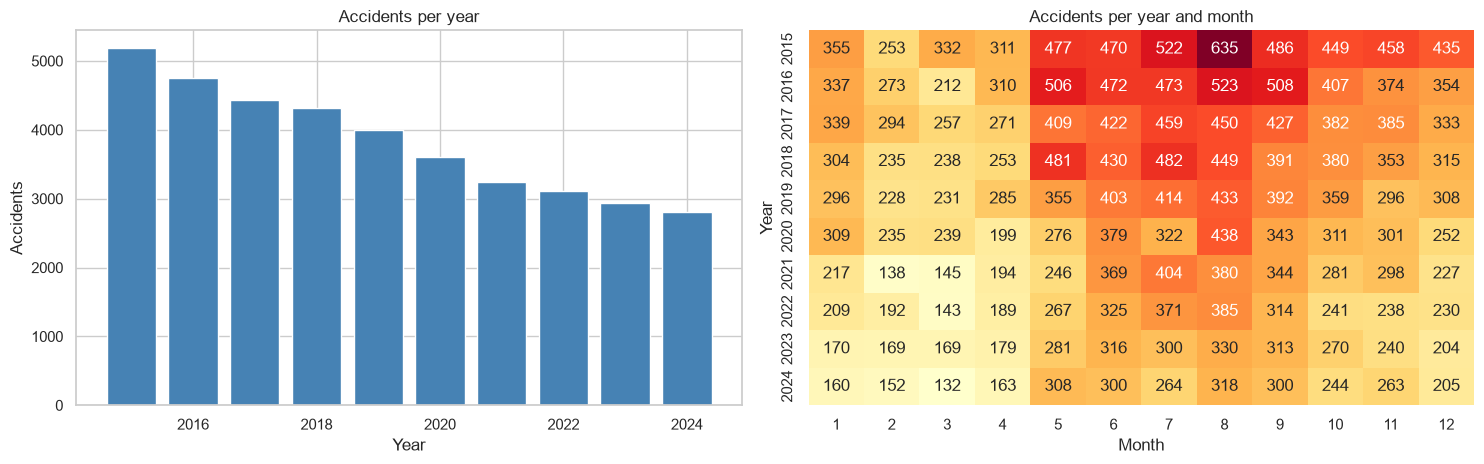

Change 2015 -> 2024: 5183 -> 2809 (-46 %)
Month with most accidents (all years): 8
Month with fewest accidents (all years): 3


In [2888]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

per_year = df_accidents.groupby("vvonn").size()
axes[0].bar(per_year.index, per_year.values, color="steelblue")
axes[0].set_title("Accidents per year")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Accidents")

heat = df_accidents.groupby(["vvonn", "kkonn"]).size().unstack()
sns.heatmap(heat, annot=True, fmt="d", cmap="YlOrRd", cbar=False, ax=axes[1])
axes[1].set_title("Accidents per year and month")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("Year")

plt.tight_layout(); plt.show()

print(f"Change 2015 -> 2024: {per_year.iloc[0]} -> {per_year.iloc[-1]} "
      f"({(per_year.iloc[-1] / per_year.iloc[0] - 1) * 100:.0f} %)")
print("Month with most accidents (all years):", df_accidents.groupby('kkonn').size().idxmax())
print("Month with fewest accidents (all years):", df_accidents.groupby('kkonn').size().idxmin())

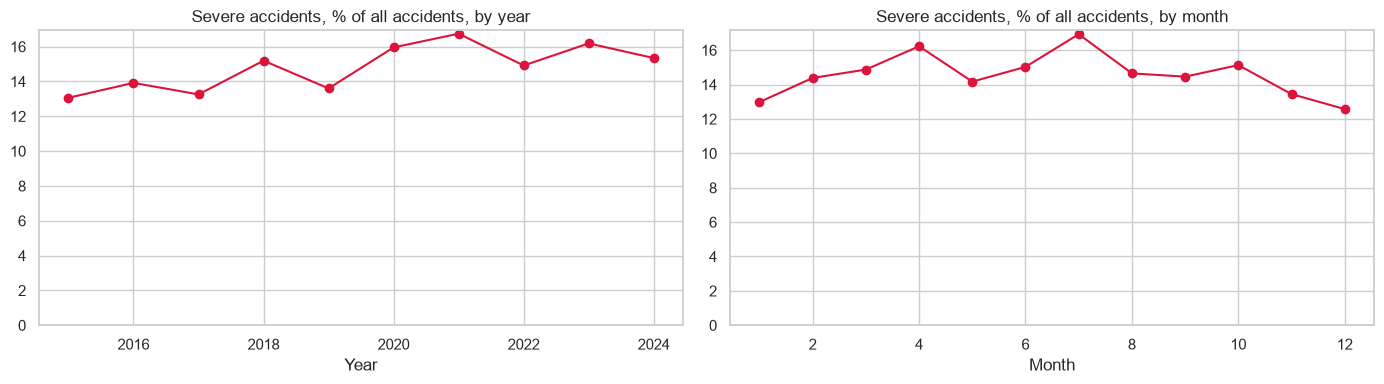

Overall share of severe accidents: 14.6 %
Lowest month: 12 (12.6 %) | highest month: 7 (16.9 %)


In [2889]:
# Share of severe accidents (fatal or serious injury) by year and by month
is_severe = df_accidents["vakav"].isin([1, 3])
share_year = is_severe.groupby(df_accidents["vvonn"]).mean() * 100
share_month = is_severe.groupby(df_accidents["kkonn"]).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(share_year.index, share_year.values, marker="o", color="crimson")
axes[0].set_title("Severe accidents, % of all accidents, by year")
axes[0].set_xlabel("Year"); axes[0].set_ylim(0, None)
axes[1].plot(share_month.index, share_month.values, marker="o", color="crimson")
axes[1].set_title("Severe accidents, % of all accidents, by month")
axes[1].set_xlabel("Month"); axes[1].set_ylim(0, None)
plt.tight_layout(); plt.show()

print(f"Overall share of severe accidents: {is_severe.mean() * 100:.1f} %")
print("Lowest month:", share_month.idxmin(), f"({share_month.min():.1f} %) | highest month:",
      share_month.idxmax(), f"({share_month.max():.1f} %)")


### 2.4 Weather data (Finnish Meteorological Institute)
**Source:** FMI open data WFS, stored query `fmi::observations::weather::daily::multipointcoverage` (daily observations from all weather stations in the bounding box of Finland).

**Variables requested**

| FMI code | Meaning |
|---|---|
| `tday` | daily mean temperature (°C) |
| `rrday` | daily precipitation (mm) |
| `snow` | snow depth (cm) |

**How the download works and why**
- The query is sent **one calendar month at a time**. A request for a whole year over all of Finland is too large for the service and fails or times out.
- Each downloaded month is saved to `datasets/fmi_cache/`. If a download is interrupted or a month fails, just **run the cell again**: finished months are read from disk, only missing ones are fetched.
- Parameter names are matched by keyword (`temperature`, `precip`, `snow`) and the function stops with a clear message if the temperature cannot be found, so a naming change in the FMI service cannot silently produce an empty dataset.
- If a full-month request fails, the function automatically retries it as two half-month requests.

In [2890]:
weather_parts, failed_months = [], []
for year in YEARS:
    for month in range(1, 13):
        part = load_weather_month(year, month)
        if part is None:
            failed_months.append(f"{year}-{month:02d}")
        else:
            weather_parts.append(part)

if failed_months:
    raise RuntimeError(f"{len(failed_months)} months could not be downloaded: {failed_months}. "
                       "Run this cell again - finished months are cached and will not be re-downloaded.")

df_weather_daily = pd.concat(weather_parts, ignore_index=True).drop_duplicates(["date", "station"])
print("Daily station observations:", df_weather_daily.shape)
display(df_weather_daily.head())

Daily station observations: (994322, 6)


,date,station,tday,rrday,snow,location
0,2015-01-01,Jomala Maarianhamina lentoasema,4.3,NaN,NaN,"{'fmisid': 100907, 'latitude': 60.12467, 'long..."
1,2015-01-01,Parainen Utö,4.6,5.0,-1.0,"{'fmisid': 100908, 'latitude': 59.77909, 'long..."
2,2015-01-01,Lemland Nyhamn,4.7,NaN,NaN,"{'fmisid': 100909, 'latitude': 59.95911, 'long..."
3,2015-01-01,Jomala Jomalaby,3.4,8.5,5.0,"{'fmisid': 100917, 'latitude': 60.17824, 'long..."
4,2015-01-01,Hammarland Märket,3.7,NaN,NaN,"{'fmisid': 100919, 'latitude': 60.30098, 'long..."


In [2891]:
# Weather data quality check: restrict to 2015-2024 and verify coverage

# Work on a copy
w = df_weather_daily.copy()

# Drop rows outside of 2015-2024
w['year_check'] = w['date'].dt.year
w = w[w['year_check'].isin(YEARS)]

# Coverage per month: how many distinct days and stations have observations
cover = (w.assign(vuosi=w["date"].dt.year, kuukausi=w["date"].dt.month)
          .groupby(["vuosi", "kuukausi"])
          .agg(days=("date", "nunique"), stations=("station", "nunique")))

print("--- FMI Säädatan Laatutarkastus ---")
print("Months covered:", len(cover), "(odotettu: 120)")
print("Days with data per month  : min", cover["days"].min(), "| max", cover["days"].max())
print("Stations per month        : min", cover["stations"].min(), "| max", cover["stations"].max())
print("\nShare of missing values:")
print(w[["tday", "rrday", "snow"]].isna().mean().round(3))
print("\nValue ranges:")
display(w[["tday", "rrday", "snow"]].describe().T)

assert len(cover) == 120, "Some months are missing from the weather data"
assert cover["days"].min() >= 28, "A month has fewer than 28 days of observations"


--- FMI Säädatan Laatutarkastus ---
Months covered: 120 (odotettu: 120)
Days with data per month  : min 28 | max 31
Stations per month        : min 266 | max 291

Share of missing values:
tday    0.284
rrday   0.292
snow     0.32
dtype: float64

Value ranges:


,count,mean,std,min,25%,50%,75%,max
tday,711439.0,4.320256972136754,9.59810573882144,-42.4,-1.6,3.9,12.2,27.6
rrday,703686.0,1.3028001125501998,4.107019150782284,-1.0,-1.0,0.1,1.8,115.3
snow,675796.0,13.845866208145653,24.088719602651068,-1.0,-1.0,-1.0,23.0,143.0


**Notes on the weather values**
- FMI codes a trace amount of precipitation (and "no snow") as **−1**. These values are set to 0 in the preparation phase.
- Snow depth is measured only at some stations and mostly in winter. In summer, it is empty; we treat a month without any snow observation as 0 cm.
- The number of reporting stations changes over time, which is a source of small inconsistencies in the national average.



The `describe()` method of pandas produces summary statistics for each column of a Weather DataFrame. For numeric columns it reports the number of non-missing values (count), the mean, the standard deviation, the minimum and maximum, and the 25th, 50th (median) and 75th percentiles. With the option `include='all'` enabled, it also summarises non-numeric columns by reporting the number of unique values, the most frequent value and its frequency.


In [2892]:
df_weather_daily.describe(include='all')

,date,station,tday,rrday,snow,location
count,994322,994322,711638.0,703866.0,675972.0,349228
unique,NaN,309,NaN,NaN,NaN,362
top,NaN,Jomala Maarianhamina lentoasema,NaN,NaN,NaN,"{'fmisid': 100908, 'latitude': 59.77909, 'long..."
freq,NaN,3654,NaN,NaN,NaN,1286
mean,2019-12-12 05:24:44.363415,NaN,4.316960870554974,1.3026635751691373,13.847196333575948,NaN
min,2015-01-01 00:00:00,NaN,-42.4,-1.0,-1.0,NaN
25%,2017-05-31 00:00:00,NaN,-1.6,-1.0,-1.0,NaN
50%,2019-12-05 00:00:00,NaN,3.9,0.1,-1.0,NaN
75%,2022-06-17 00:00:00,NaN,12.2,1.8,23.0,NaN
max,2025-01-01 00:00:00,NaN,27.6,115.3,143.0,NaN


In [2893]:
# Weather measurement locations
df_weather_daily

,date,station,tday,rrday,snow,location
0,2015-01-01,Jomala Maarianhamina lentoasema,4.3,NaN,NaN,"{'fmisid': 100907, 'latitude': 60.12467, 'long..."
1,2015-01-01,Parainen Utö,4.6,5.0,-1.0,"{'fmisid': 100908, 'latitude': 59.77909, 'long..."
2,2015-01-01,Lemland Nyhamn,4.7,NaN,NaN,"{'fmisid': 100909, 'latitude': 59.95911, 'long..."
3,2015-01-01,Jomala Jomalaby,3.4,8.5,5.0,"{'fmisid': 100917, 'latitude': 60.17824, 'long..."
4,2015-01-01,Hammarland Märket,3.7,NaN,NaN,"{'fmisid': 100919, 'latitude': 60.30098, 'long..."
...,...,...,...,...,...,...
1026710,2025-01-01,Kittilä Lompolonvuoma,-16.6,-1.0,NaN,NaN
1026711,2025-01-01,Kuusamo Ruka Talvijärvi,-8.3,NaN,NaN,NaN
1026712,2025-01-01,Espoo Nuuksio,-3.6,4.9,5.0,NaN
1026713,2025-01-01,Mikkeli Lentoasema AWOS,-6.1,3.3,18.0,NaN


## 3. Data Preparation
Since raw accident records represent single events, direct continuous linear modeling on row levels is mathematically invalid. We perform an **Aggregation step** to compute total accidents grouped by month, establishing a true continuous numeric target variable suitable for Logistic Regression modeling.

### 3.1 Accident Data Preparation

#### 3.1.1 Readable Column Names

In [2894]:
# Readable column names for presentation
readable_col_names =  {
"vvonn" : "vuosi",
"kkonn" : "kuukausi",
"kello" : "kello",
"vakav" : "vakavuus",
"onntyyppi" : "onnettomuustyyppi",
"lkmhapa" : "henkilö- ja pakettiautot",
"lkmlaka" : "linja- ja kuorma-autot",
"lkmjk" : "jalankulkijat",
"lkmpp" : "polkupyörät ja kevyet sähköajoneuvot",
"lkmmo" : "mopot",
"lkmmp" : "moottoripyörät",
"lkmmuukulk" : "muut kulkuneuvot",
"x" : "x",
"y" : "y"
}
df_accidents.rename( columns=readable_col_names, inplace=True)

#### 3.1.2 Converting Class Variables to 1-hot Encoded Columns


The severity of the accident (`vakavuus`) is converted into a binary target variable. Accidents that ended in death (value 1) or serious injury (value 3) are labelled **1 (severe)**, and accidents with a lighter injury (value 2) are labelled **0 (less severe)**.

The accident type (`onnettomuustyyppi`) is a categorical variable with codes 0-9. The codes are only labels and have no order, so a model must not treat them as numbers. Each type is therefore converted with 1-hot encoding method into its own column with the value 1 if the accident was of that type and 0 otherwise. At the end, the original `onnettomuustyyppi` column is dropped.

In [2895]:
# Convert accident severity to 0 or 1
df_accidents['vakavuus'] = df_accidents['vakavuus'].isin([1, 3]).astype(int)

accident_types_raw = {
0 : "samat ajosuunnat (ajo suoraan)",
1 : "samat ajosuunnat (ajo kääntyen)",
2 : "vastakkaiset ajosuunnat (ajo suoraan)",
3 : "vastakkaiset ajosuunnat (ajo kääntyen)",
4 : "risteävät ajosuunnat (ajo suoraan)",
5 : "risteävät ajosuunnat (ajo kääntyen)",
6 : "jalankulkijaonnettomuus (suojatiellä)",
7 : "jalankulkijaonnettomuus (muualla)",
8 : "tieltä suistuminen",
9 : "muu onnettomuus"
}

# Create columns and assign integer 1 or 0
for type_number, column_name in accident_types_raw.items():
    df_accidents[column_name] = [1 if accident_type == type_number else 0 for accident_type in df_accidents['onnettomuustyyppi']]

# Drop onnettomuustyyppi column
df_accidents.drop('onnettomuustyyppi', axis=1, inplace=True)

#### 3.1.3 Converting Cyclical Time Variable to Components
Time is a cyclical variable that overflows at midnight. To make it compatible with logistic regression, we break it down to sine and cosine components of a 24-hour cycle.

The hours are in String datatype and in format XX.00-XX.59.

We take the first two characters of each string in column 'kello' and convert that to float.

In [2896]:
df_accidents['tunti'] = df_accidents['kello'].str[:2].astype(float)

# drop the row(s) with missing time
df_accidents = df_accidents.dropna(subset=['tunti'])

# tunti is integer
df_accidents['tunti'] = df_accidents['tunti'].astype(int)

df_accidents["sin_tunti"] = np.sin(2 * np.pi * df_accidents["tunti"] / 24)
df_accidents["cos_tunti"] = np.cos(2 * np.pi * df_accidents["tunti"] / 24)

# Drop tunti
df_accidents.drop(columns=['tunti'], inplace=True)

#### 3.1.4 Accident Data Location Formatting

In [2897]:
import geopandas as gpd

# 1. Convert EPSG:3067 coordinates (x, y) directly into a GeoDataFrame
accidents_gdf = gpd.GeoDataFrame(
    df_accidents,
    geometry=gpd.points_from_xy(df_accidents["x"], df_accidents["y"]),
    crs="EPSG:3067"
)

# 2. Re-project the ENTIRE dataset at once to WGS84 (EPSG:4326 - lat/lon)
accidents_gdf = accidents_gdf.to_crs(epsg=4326)

### 3.2 Weather Data Preparation


#### 3.2.1 Daily Station Values to One Value Per Month
1. Clean the codes (−1 = trace → 0).
2. Average over all stations to get one national value **per day**.
3. Aggregate the days into **monthly features**: mean temperature, total precipitation, mean snow depth and the share of days with a mean temperature below 0 °C.

In [2898]:
# 1. Create a copy of the raw daily weather table
d_stations = df_weather_daily.copy()

# Clean up trace amounts and missing codes as we did before
d_stations["rrday"] = d_stations["rrday"].clip(lower=0)
d_stations["snow"] = d_stations["snow"].clip(lower=0)

# Extract year and month fields from the datetime index
d_stations["vuosi"] = d_stations["date"].dt.year
d_stations["kuukausi"] = d_stations["date"].dt.month

# 2. Aggregation Phase: Group by Year, Month, Station Name, and Location coordinates!
# This collapses the 10-minute/daily records into a clean Monthly Station Dataset.
df_weather_monthly_stations = d_stations.groupby(
    ["vuosi", "kuukausi", "station", "location"],
    as_index=False
).agg(
    keski_lampotila=("tday", "mean"),       # Monthly mean temp for THIS specific station
    sade_summa=("rrday", "sum"),            # Monthly total rain for THIS specific station
    lumensyvyys=("snow", "mean"),          # Monthly mean snow depth for THIS specific station
    pakkaspaivat_osuus=("tday", lambda s: (s.dropna() < 0).mean()) # Frost days share for THIS station
)

# Handle missing snow values for the stations safely
df_weather_monthly_stations["lumensyvyys"] = df_weather_monthly_stations["lumensyvyys"].fillna(0)

print("Monthly weather dataset with unique locations constructed successfully!")
print(f"Dataset Shape (Monthly Station Records): {df_weather_monthly_stations.shape}")

# Display the first 14 rows to let Abu Shahab see the station names and coordinates
display(df_weather_monthly_stations.head(14))


Monthly weather dataset with unique locations constructed successfully!
Dataset Shape (Monthly Station Records): (17420, 8)


,vuosi,kuukausi,station,location,keski_lampotila,sade_summa,lumensyvyys,pakkaspaivat_osuus
0,2015,1,Alajärvi Möksy,"{'fmisid': 101533, 'latitude': 63.08898, 'long...",-6.529032258064516,107.39999999999999,34.48275862068966,0.9032258064516129
1,2015,1,Alavus Sulkavankylä,"{'fmisid': 101305, 'latitude': 62.44881, 'long...",NaN,62.9,16.967741935483872,NaN
2,2015,1,Asikkala Pulkkilanharju,"{'fmisid': 101185, 'latitude': 61.26521, 'long...",-3.761290322580645,0.0,0.0,0.7419354838709677
3,2015,1,Asikkala Urajärvi,"{'fmisid': 101168, 'latitude': 61.13694, 'long...",NaN,62.9,27.258064516129032,NaN
4,2015,1,Enonkoski Simanala,"{'fmisid': 101446, 'latitude': 62.05563, 'long...",NaN,68.2,32.225806451612904,NaN
5,2015,1,Enontekiö Hetta,"{'fmisid': 101974, 'latitude': 68.38606, 'long...",NaN,39.6,58.25806451612903,NaN
6,2015,1,Enontekiö Kaaresuvanto,"{'fmisid': 101968, 'latitude': 68.44298, 'long...",NaN,38.0,51.67741935483871,NaN
7,2015,1,Enontekiö Kilpisjärvi Saana,"{'fmisid': 102017, 'latitude': 69.04277, 'long...",-12.483870967741936,0.0,0.0,1.0
8,2015,1,Enontekiö Kilpisjärvi kyläkeskus,"{'fmisid': 102016, 'latitude': 69.04948, 'long...",-14.693548387096774,29.2,53.12903225806452,0.967741935483871
9,2015,1,Enontekiö Näkkälä,"{'fmisid': 102019, 'latitude': 68.60301, 'long...",-14.635483870967741,15.2,55.225806451612904,1.0


Convert daily FMI observations into monthly averages
WHILE KEEPING the unique Station Name and its Geographic Location!


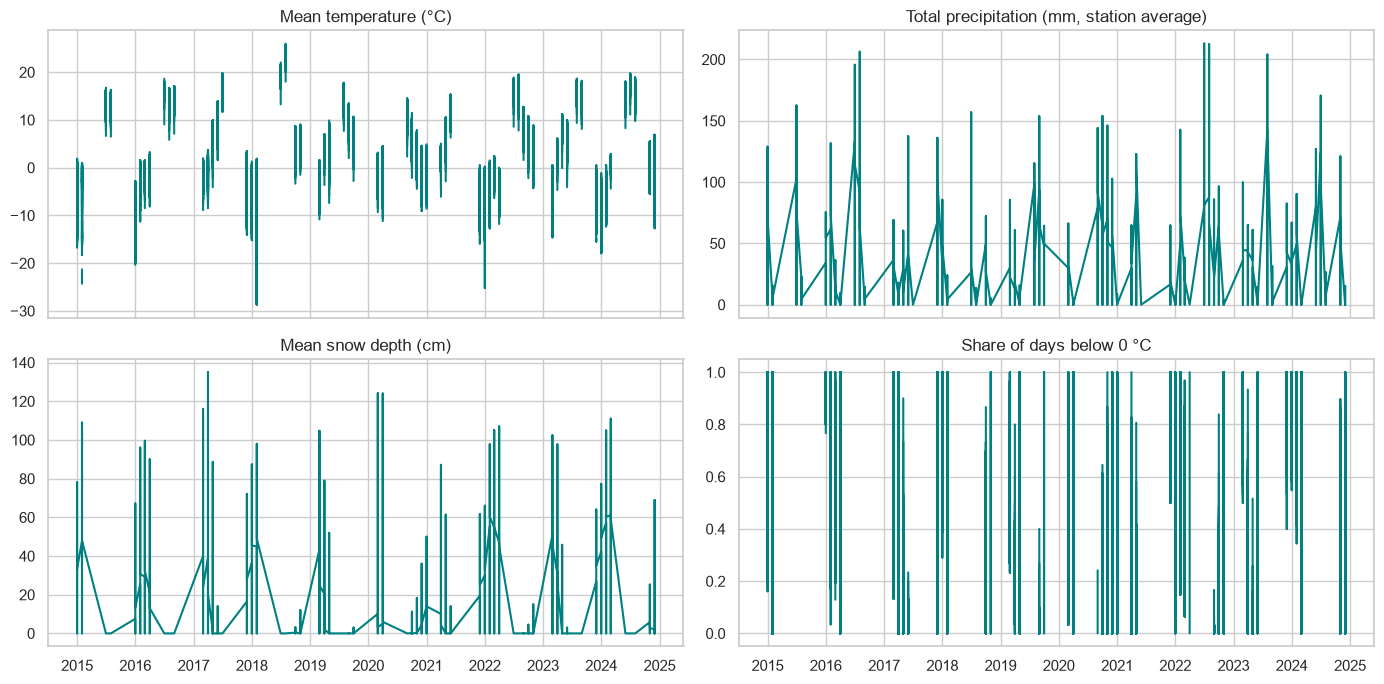

In [2899]:
WX_FEATURES = ["keski_lampotila", "sade_summa", "lumensyvyys", "pakkaspaivat_osuus"]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
x = pd.to_datetime(dict(year=df_weather_monthly_stations["vuosi"], month=df_weather_monthly_stations["kuukausi"], day=1))
titles = ["Mean temperature (°C)", "Total precipitation (mm, station average)",
          "Mean snow depth (cm)", "Share of days below 0 °C"]
for ax, col, title in zip(axes.ravel(), WX_FEATURES, titles):
    ax.plot(x, df_weather_monthly_stations[col], color="teal")
    ax.set_title(title)
plt.tight_layout(); plt.show()

#### 3.2.2 Weather Data Location Formatting


In [2900]:
# Function for converting strings to coordinates
def location_string_to_lonlat(string):
        string = string.strip("{}")
        lon_lat_dict = dict( item.replace("'","").split(": ") for item in string.split(", ") )
        lon = float(lon_lat_dict["longitude"])
        lat = float(lon_lat_dict["latitude"])
        return lon, lat

df_weather_monthly_stations["x"] = [ location_string_to_lonlat(location_string)[0] for location_string in df_weather_monthly_stations["location"] ]
df_weather_monthly_stations["y"] = [ location_string_to_lonlat(location_string)[1] for location_string in df_weather_monthly_stations["location"] ]

# Put weather data to GeoDataFrame
weather_gdf = gpd.GeoDataFrame(
    df_weather_monthly_stations,
    geometry=gpd.points_from_xy(df_weather_monthly_stations["x"], df_weather_monthly_stations["y"]),
    crs="EPSG:4326"
)
weather_gdf = weather_gdf.to_crs(epsg=4326)


In [2901]:
weather_gdf

,vuosi,kuukausi,station,location,keski_lampotila,sade_summa,lumensyvyys,pakkaspaivat_osuus,x,y,geometry
0,2015,1,Alajärvi Möksy,"{'fmisid': 101533, 'latitude': 63.08898, 'long...",-6.529032258064516,107.39999999999999,34.48275862068966,0.9032258064516129,24.26084,63.08898,POINT (24.26084 63.08898)
1,2015,1,Alavus Sulkavankylä,"{'fmisid': 101305, 'latitude': 62.44881, 'long...",NaN,62.9,16.967741935483872,NaN,23.55334,62.44881,POINT (23.55334 62.44881)
2,2015,1,Asikkala Pulkkilanharju,"{'fmisid': 101185, 'latitude': 61.26521, 'long...",-3.761290322580645,0.0,0.0,0.7419354838709677,25.52021,61.26521,POINT (25.52021 61.26521)
3,2015,1,Asikkala Urajärvi,"{'fmisid': 101168, 'latitude': 61.13694, 'long...",NaN,62.9,27.258064516129032,NaN,25.79227,61.13694,POINT (25.79227 61.13694)
4,2015,1,Enonkoski Simanala,"{'fmisid': 101446, 'latitude': 62.05563, 'long...",NaN,68.2,32.225806451612904,NaN,29.04407,62.05563,POINT (29.04407 62.05563)
...,...,...,...,...,...,...,...,...,...,...,...
17415,2024,12,Ylitornio Meltosjärvi,"{'fmisid': 101908, 'latitude': 66.52952, 'long...",-3.4,6.0,13.0,1.0,24.6496,66.52952,POINT (24.6496 66.52952)
17416,2024,12,Ylivieska Vähäkangas,"{'fmisid': 101691, 'latitude': 64.06638, 'long...",NaN,0.1,4.0,NaN,24.67714,64.06638,POINT (24.67714 64.06638)
17417,2024,12,Ylivieska lentokenttä,"{'fmisid': 101690, 'latitude': 64.05029, 'long...",3.4,0.0,6.0,0.0,24.72468,64.05029,POINT (24.72468 64.05029)
17418,2024,12,Ähtäri Inha,"{'fmisid': 101520, 'latitude': 62.55461, 'long...",5.3,0.9,0.0,0.0,24.14239,62.55461,POINT (24.14239 62.55461)


### 3.3 Combining the Datasets Based on Location Data

In [2902]:
# Join dataframes
joined_gdf = gpd.sjoin_nearest(left_df=accidents_gdf, right_df=weather_gdf, how="left", lsuffix="accident", rsuffix="weather", distance_col="weather_distance")
joined_gdf.drop_duplicates(subset=["FID"], inplace=True)


# raw copy if needed later
joined_gdf_raw = joined_gdf.copy(deep=True)

# drop columns not needed in modeling
joined_gdf.drop(columns=[
    'FID', 'id', 'geom', 'vuosi_accident', 'kuukausi_accident', 'kello', 'x_accident', 'y_accident', 'geometry', 'index_weather', 'vuosi_weather',
       'kuukausi_weather', 'station', 'location', 'x_weather', 'y_weather', 'weather_distance'
], inplace=True)


C:\Users\Local Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\geopandas\array.py:438: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


Visualization of accident and weather observation locations can be seen here:

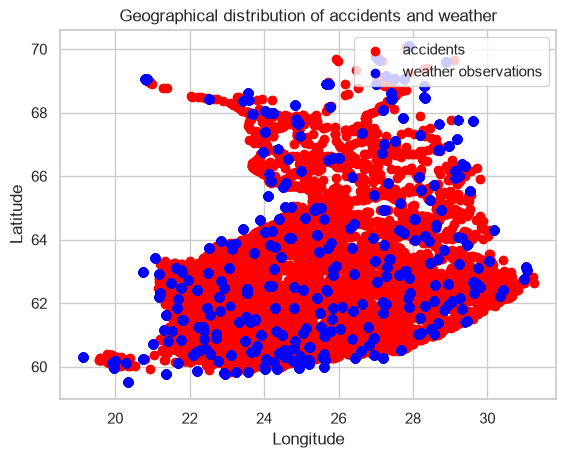

In [2903]:
# Grap showing accident and weather data
weather_points = weather_gdf.geometry
accident_points = joined_gdf_raw.geometry

plt.scatter(accident_points.x, accident_points.y, color="red", label="accidents")
plt.scatter( weather_points.x, weather_points.y, color="blue", label="weather observations" )

# Add labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographical distribution of accidents and weather')

# Show legend
plt.legend( loc="upper right",  )

# Enable grid
plt.grid(True)

# Display the plot
plt.show()


### 3.4 Separating Training and Testing Data

The data is divided into training (75%) and testing (25%). To guarantee same results across every run, a fixed **random_state** is applied.

In [2904]:
from sklearn.model_selection import train_test_split

joined_gdf = joined_gdf.dropna()

y = joined_gdf['vakavuus']
X = joined_gdf.drop(columns= 'vakavuus')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

We create variables X_train_acc and _X_test_acc by dropping the columns fetched from Weather Data to test if having seasonal features included has any effect on the Model's results.

In [2905]:
wx_cols = ['keski_lampotila', 'sade_summa', 'lumensyvyys', 'pakkaspaivat_osuus']

X_train_acc = X_train.drop(columns=wx_cols)
X_test_acc  = X_test.drop(columns=wx_cols)

### 3.4 Feature Scaling

To prepare the features for moding, we standardize them using **Scikit-Learn's StandardScaler**. This transforms the features to have a mean of 0 and a standard deviation of 1.

The scaling is done due to Logistic Regression is sensitive to the scale of input features. Features with larger numeric ranges could otherwise dominate the model's coefficients.

Scaler is fitted strictly on the training set **X_train** to learn its mean and variance. These values are then applied to the test set **X_test**, ensuring no information from the testing data leaks into the training process.

In [2906]:
## Scale features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on X_train data only to learn its mean and variance
X_train_scaled = scaler.fit_transform(X_train)
# Scale X_test using the exact same mean and variance learned from X_train
X_test_scaled = scaler.transform(X_test)

# Wrap results back into a DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)

# assert the list sizes, small check.
assert len(X_train_scaled) == len(y_train) and len(X_test_scaled) == len(y_test)

print("Data Preparation Completed:")
print(f"Training set size: {X_train.shape[0]} samples.")
print(f"Testing set size: {X_test.shape[0]} samples.")

print("\n1. Without standardize features train data :")
display(X_train.head(5))

print("\n2. With standardize features train data (for the Logistic regression) :")
display(X_train_scaled.head(5))



Data Preparation Completed:
Training set size: 22631 samples.
Testing set size: 7544 samples.

1. Without standardize features train data :


,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,mopot,moottoripyörät,muut kulkuneuvot,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus,sin_tunti,cos_tunti,keski_lampotila,sade_summa,lumensyvyys,pakkaspaivat_osuus
15462,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,-0.2588190451025208,-0.9659258262890683,4.313793103448275,36.699999999999996,0.0,0.0
2533,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,-0.4999999999999997,-0.8660254037844388,-7.583870967741936,0.0,0.0,0.7741935483870968
25738,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-0.25881904510252157,0.9659258262890681,6.376666666666667,0.0,0.0,0.06666666666666667
4999,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-0.9659258262890684,0.2588190451025203,15.863333333333333,105.4,0.0,0.0
2867,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,-0.8660254037844385,-0.5000000000000004,0.09666666666666666,0.0,0.0,0.4666666666666667



2. With standardize features train data (for the Logistic regression) :


,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,mopot,moottoripyörät,muut kulkuneuvot,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus,sin_tunti,cos_tunti,keski_lampotila,sade_summa,lumensyvyys,pakkaspaivat_osuus
0,0.8075592667428134,-0.31252153187653064,-0.3251371696649563,-0.46088674111936156,-0.3073142376217553,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,-0.31135429306062296,-0.28107396645045496,-0.22656846954670098,2.328119808766643,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,-0.569747516846614,-0.2960790532721188,-0.02905661265189563,-1.083209159885911,-0.08259411836534576,0.43188185268871826,-0.47377832790706,-0.8045559380535862
1,-0.1746449448795121,-0.31252153187653064,-0.3251371696649563,1.935237274105144,-0.3073142376217553,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,3.2117752100668566,-0.28107396645045496,-0.22656846954670098,-0.42953115910721323,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,-0.569747516846614,-0.2960790532721188,-0.38200851077829545,-0.9241205940442345,-1.362585809251329,-0.7096297943017362,-0.47377832790706,1.2343815686281736
2,-0.1746449448795121,-0.31252153187653064,-0.3251371696649563,-0.46088674111936156,-0.3073142376217553,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,-0.31135429306062296,-0.28107396645045496,-0.22656846954670098,-0.42953115910721323,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,1.7551634196401733,-0.2960790532721188,-0.029056612651896768,1.9932093488875209,0.1393369266253839,-0.7096297943017362,-0.47377832790706,-0.6289807638671013
3,-0.1746449448795121,-0.31252153187653064,-0.3251371696649563,-0.46088674111936156,-0.3073142376217553,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,-0.31135429306062296,-0.28107396645045496,-0.22656846954670098,-0.42953115910721323,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,1.7551634196401733,-0.2960790532721188,-1.0638592184543725,0.8671620220038045,1.1599452103087222,2.568717006591831,-0.47377832790706,-0.8045559380535862
4,-0.1746449448795121,-0.31252153187653064,-0.3251371696649563,-0.46088674111936156,2.7632502266687275,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,3.2117752100668566,-0.28107396645045496,-0.22656846954670098,-0.42953115910721323,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,-0.569747516846614,-0.2960790532721188,-0.9176617553850901,-0.3412356062756561,-0.5362871093758141,-0.7096297943017362,-0.47377832790706,0.424470281251808


### 3.5 Scale Features (accident columns only, no weather)

In [2907]:
scaler_acc = StandardScaler()

# Fit the scaler on X_train_acc data only to learn its mean and variance
X_train_acc_scaled = scaler_acc.fit_transform(X_train_acc)
# Scale X_test_acc using the exact same mean and variance learned from X_train_acc
X_test_acc_scaled = scaler_acc.transform(X_test_acc)

# Wrap results back into a DataFrame
X_train_acc_scaled = pd.DataFrame(X_train_acc_scaled, columns=X_train_acc.columns)
X_test_acc_scaled = pd.DataFrame(X_test_acc_scaled, columns=X_train_acc.columns)

# assert the list sizes, small check.
assert len(X_train_acc_scaled) == len(y_train) and len(X_test_acc_scaled) == len(y_test)

print("Data Preparation Completed (accident columns only):")
print(f"Training set size: {X_train_acc.shape[0]} samples.")
print(f"Testing set size: {X_test_acc.shape[0]} samples.")

print("\n1. Without standardize features train data :")
display(X_train_acc.head(5))

print("\n2. With standardize features train data (for the Logistic regression) :")
display(X_train_acc_scaled.head(5))

Data Preparation Completed (accident columns only):
Training set size: 22631 samples.
Testing set size: 7544 samples.

1. Without standardize features train data :


,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,mopot,moottoripyörät,muut kulkuneuvot,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus,sin_tunti,cos_tunti
15462,2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,-0.2588190451025208,-0.9659258262890683
2533,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,-0.4999999999999997,-0.8660254037844388
25738,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-0.25881904510252157,0.9659258262890681
4999,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-0.9659258262890684,0.2588190451025203
2867,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,-0.8660254037844385,-0.5000000000000004



2. With standardize features train data (for the Logistic regression) :


,henkilö- ja pakettiautot,linja- ja kuorma-autot,jalankulkijat,polkupyörät ja kevyet sähköajoneuvot,mopot,moottoripyörät,muut kulkuneuvot,samat ajosuunnat (ajo suoraan),samat ajosuunnat (ajo kääntyen),vastakkaiset ajosuunnat (ajo suoraan),vastakkaiset ajosuunnat (ajo kääntyen),risteävät ajosuunnat (ajo suoraan),risteävät ajosuunnat (ajo kääntyen),jalankulkijaonnettomuus (suojatiellä),jalankulkijaonnettomuus (muualla),tieltä suistuminen,muu onnettomuus,sin_tunti,cos_tunti
0,0.8075592667428134,-0.31252153187653064,-0.3251371696649563,-0.46088674111936156,-0.3073142376217553,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,-0.31135429306062296,-0.28107396645045496,-0.22656846954670098,2.328119808766643,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,-0.569747516846614,-0.2960790532721188,-0.02905661265189563,-1.083209159885911
1,-0.1746449448795121,-0.31252153187653064,-0.3251371696649563,1.935237274105144,-0.3073142376217553,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,3.2117752100668566,-0.28107396645045496,-0.22656846954670098,-0.42953115910721323,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,-0.569747516846614,-0.2960790532721188,-0.38200851077829545,-0.9241205940442345
2,-0.1746449448795121,-0.31252153187653064,-0.3251371696649563,-0.46088674111936156,-0.3073142376217553,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,-0.31135429306062296,-0.28107396645045496,-0.22656846954670098,-0.42953115910721323,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,1.7551634196401733,-0.2960790532721188,-0.029056612651896768,1.9932093488875209
3,-0.1746449448795121,-0.31252153187653064,-0.3251371696649563,-0.46088674111936156,-0.3073142376217553,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,-0.31135429306062296,-0.28107396645045496,-0.22656846954670098,-0.42953115910721323,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,1.7551634196401733,-0.2960790532721188,-1.0638592184543725,0.8671620220038045
4,-0.1746449448795121,-0.31252153187653064,-0.3251371696649563,-0.46088674111936156,2.7632502266687275,-0.30191771793211514,-0.2238021647626181,-0.42439556078175883,3.2117752100668566,-0.28107396645045496,-0.22656846954670098,-0.42953115910721323,-0.2571812151296351,-0.24727141337650083,-0.1929125996248059,-0.569747516846614,-0.2960790532721188,-0.9176617553850901,-0.3412356062756561


## 4. Modeling

### 4.1 Logistic Regression: Combined features
A logistic regression model is trained on the scaled features (accident characteristics and monthly weather) and the training target `vakavuus`.

With the data prepared, we initialize and train a **LogisticRegression** model from Scikit-Learn. The model is trained using the **X_train_scaled** and **y_train** that includes data and columns from Statistics Finland and Finnish Meteorological Institure.


In [2908]:
from sklearn.linear_model import LogisticRegression

# Model initialization and training
model1 = LogisticRegression(random_state=69) # class_weight='balanced' poistettu
model1.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",69
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

### 4.2 Logistic Regression: Accident features only

The same model with the same settings is trained without the weather features. Using identical settings and identical train/test accidents makes the two models directly comparable.

In [2909]:
# Model initialization and training
model_acc = LogisticRegression(random_state=69)

model_acc.fit(X_train_acc_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",69
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following a

### 4.3 Alternative Cross Validation
Cross validation instead of split validation. The model is evaluated with 10-fold cross-validation on the training data. Each fold is predicted by the model once leaving every time 9 folds for training.


Accuracy: 0.87
Confusion Matrix:
 [[19576    44]
 [ 2992    19]]


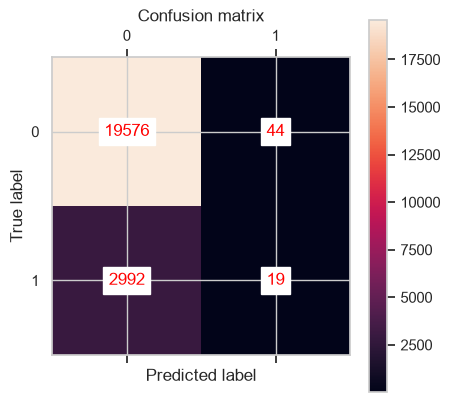

In [2910]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

# cross-validation

y_pred = cross_val_predict(estimator=model1, X=X_train_scaled, y=y_train, cv=10)

cm = confusion_matrix(y_train, y_pred)
accuracy = accuracy_score(y_train, y_pred)

print("Accuracy: %0.2f" % accuracy)
print("Confusion Matrix:\n", cm)

# visualize confusion matrix
plt.matshow(cm)
plt.title('Confusion matrix')
plt.colorbar()
plt.ylabel('True label')
plt.xlabel('Predicted label')
# include counts
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='red', backgroundcolor='white')
plt.show()

### 4.4 Alternate Model: Random Forest

We wanted to test the dataset with another Model as the Logistic Regression model results did not meet our expectations.

We set the `Random Forest Model` with the following settings:
- 250 trees,
- Max depth 12,
- at least 5 sample sper leaf,
- a random state as 42

In [2911]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    random_state=42,
    min_samples_leaf=5,
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

## 5. Evaluation

### 5.1 Logistic Regression with Weather

In [2912]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Train accuracy
print("Train accuracy:", model1.score(X_train_scaled, y_train))
# Test accuracy
print("Test accuracy: ", model1.score(X_test_scaled, y_test))

Train accuracy: 0.8658477309884671
Test accuracy:  0.8556468716861082


              precision    recall  f1-score   support

           0       0.86      1.00      0.92      6462
           1       0.39      0.01      0.02      1082

    accuracy                           0.86      7544
   macro avg       0.62      0.50      0.47      7544
weighted avg       0.79      0.86      0.79      7544



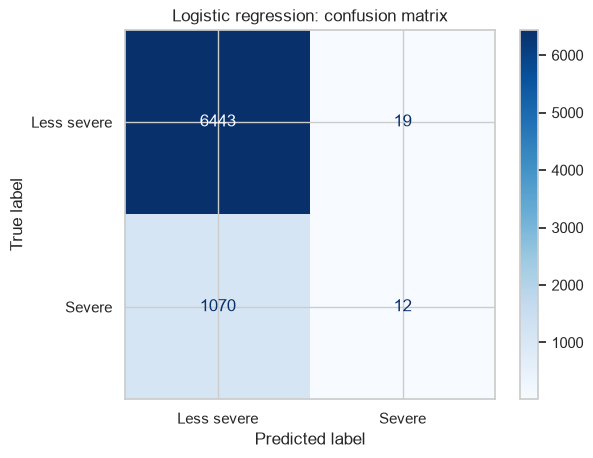

In [2913]:
pred = model1.predict(X_test_scaled)
print(classification_report(y_true=y_test, y_pred=pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred,
    display_labels=['Less severe', 'Severe'],
    cmap='Blues'
)
plt.title('Logistic regression: confusion matrix')
plt.show()

In [2914]:
print(y_train.value_counts())
print(y_test.value_counts())
print(df_accidents['vakavuus'].value_counts())

vakavuus
0    19620
1     3011
Name: count, dtype: int64
vakavuus
0    6462
1    1082
Name: count, dtype: int64
vakavuus
0    32753
1     5603
Name: count, dtype: int64


### 5.2 Logistic Regression Without Weather

In [2915]:
# Train accuracy
print("Train accuracy:", model_acc.score(X_train_acc_scaled, y_train))
# Test accuracy
print("Test accuracy: ", model_acc.score(X_test_acc_scaled, y_test))

Train accuracy: 0.8658919181653484
Test accuracy:  0.8556468716861082


              precision    recall  f1-score   support

           0       0.86      1.00      0.92      6462
           1       0.39      0.01      0.02      1082

    accuracy                           0.86      7544
   macro avg       0.62      0.50      0.47      7544
weighted avg       0.79      0.86      0.79      7544



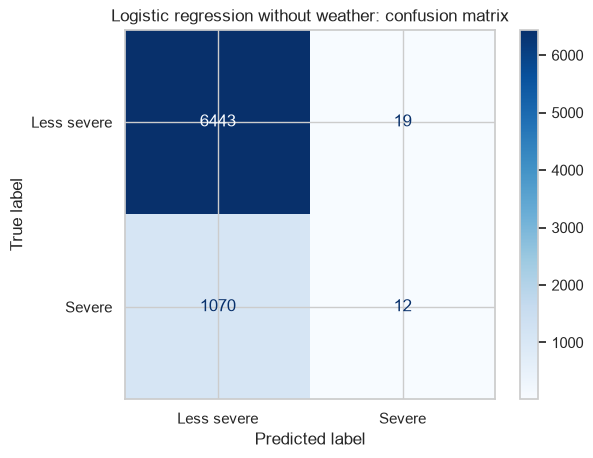

In [2916]:
pred_acc = model_acc.predict(X_test_acc_scaled)
print(classification_report(y_true=y_test, y_pred=pred_acc))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_acc,
    display_labels=['Less severe', 'Severe'],
    cmap='Blues'
)
plt.title('Logistic regression without weather: confusion matrix')
plt.show()

### 5.3 Does weather improve the prediction?

The two logistic regression models are compared with `ROC-AUC` and `PR-AUC`, which are calculated from the predicted probabilities of an accident being severe and therefore do not depend on a decision threshold.


**ROC-AUC** tells how well a model ranks severe accidents above less severe ones (0.5 is guessing, 1.0 is perfect).


**PR-AUC** focuses on the severe class and is compared with the base rate of severe accidents in the test set (about 0.14), which is the score a model without any skill would get.


In [2917]:
from sklearn.metrics import roc_auc_score, average_precision_score

proba = model1.predict_proba(X_test_scaled)[:, 1]
proba_acc = model_acc.predict_proba(X_test_acc_scaled)[:, 1]

print("With weather:    ROC-AUC", round(roc_auc_score(y_test, proba), 3),
      "| PR-AUC", round(average_precision_score(y_test, proba), 3))
print("Without weather: ROC-AUC", round(roc_auc_score(y_test, proba_acc), 3),
      "| PR-AUC", round(average_precision_score(y_test, proba_acc), 3))
print("Base rate:", round(y_test.mean(), 3))

With weather:    ROC-AUC 0.689 | PR-AUC 0.269
Without weather: ROC-AUC 0.687 | PR-AUC 0.268
Base rate: 0.143


Based on the results, it is clear that **the weather does not improve the severity prediction.** Both models are clearly above chance, so the accident characteristics contain some information about severity but the results are still almost identical.

### 5.4 Random Forest Results

In [2918]:
y_pred = rf.predict(X_test)

rf.score(X_test, y_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92      6462
           1       0.68      0.05      0.09      1082

    accuracy                           0.86      7544
   macro avg       0.77      0.52      0.51      7544
weighted avg       0.84      0.86      0.81      7544



The Random Forest model reached an accuracy of 86% on the test set of 9589 accidents.

With the `less severe` class the model performed quite well, with a precision of 87% and a recall of 99%. This means that the model almost always recognized these accidents correctly.

With the `severe` class, the model performed poorly as the recall for this was only 7% meaning it found only 7% of the severe accidents and incorrectly predicted the rest to be less severe. However, when the model predicted an accident to be severe, it was correct slightly more than a half of the time.

### 5.5 Feature Importance

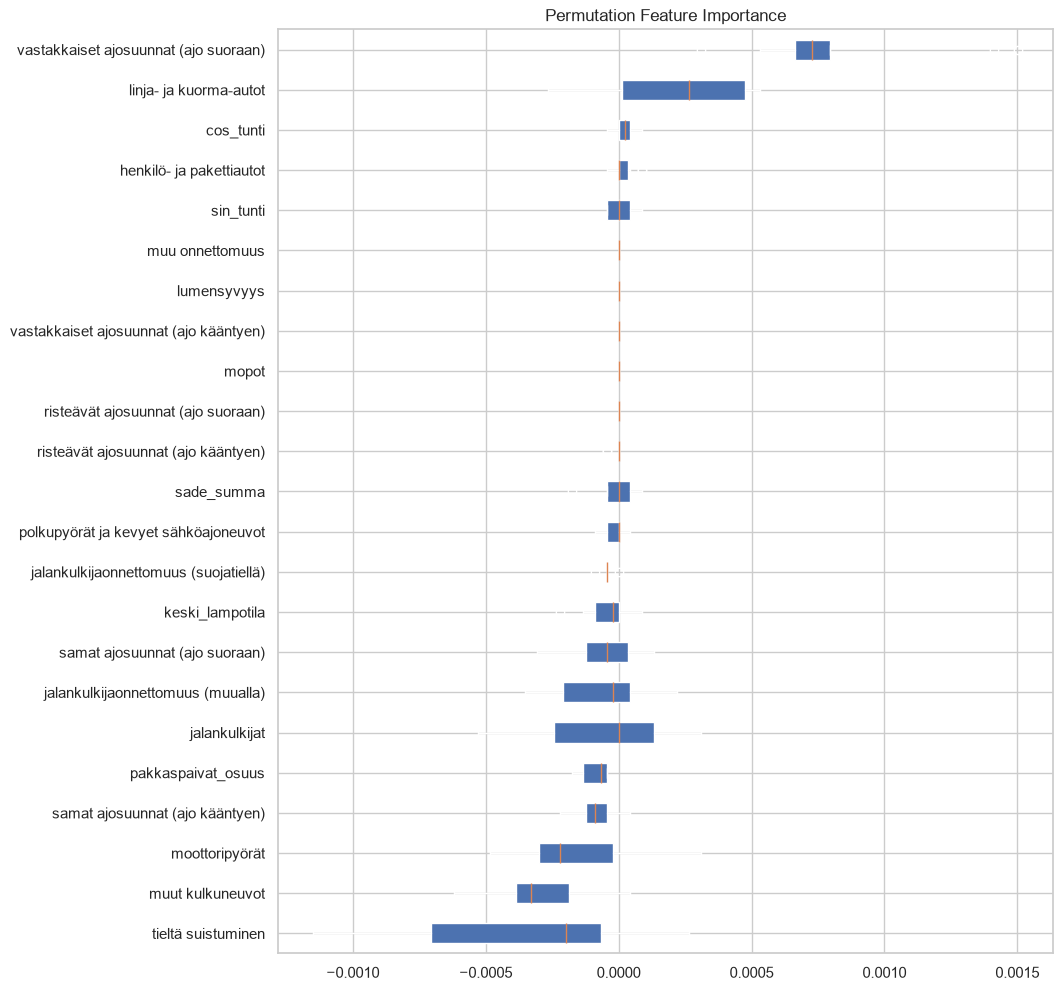

In [2919]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance using the standardized model and scaled test data
result = permutation_importance(
    model1,
    X_train_scaled,
    y_train,
    n_repeats=10,
    scoring="accuracy",
    random_state=69,
    n_jobs=-1
)

# Sort features by their mean importance score
sorted_idx = result.importances_mean.argsort()

# Plot the results
fig, ax = plt.subplots(figsize=(10, 12))

ax.boxplot(
    result.importances[sorted_idx].T,
    orientation="horizontal",
    tick_labels=X_train_scaled.columns[sorted_idx],
    patch_artist=True
)
ax.set_title("Permutation Feature Importance")


#fig.tight_layout()
plt.show()


## 6. Deployment


### 6.1 What the results tell us


The dataset was tested with two logistic regression models, one with and one without the weather variables, and also with a random forest. All of the models did poorly. Their accuracy was usually high, but their recall for severe accidents was low, which means that they were too cautious about labelling an accident as severe and predicted "less severe" for most of the accidents. The high accuracy is misleading, because the majority of the accidents are less severe, so a model that almost always predicts "less severe" is correct most of the time without really finding the severe accidents.


The main reasons are the strong class imbalance (severe accidents are only about 14% of the data) and the fact that the available variables describe the accident only partly. The models are therefore not suitable for predicting the severity of an individual accident.




### 6.2 How the results can be used
- **Informing communication.** Because weather did not explain severity, safety campaigns should not assume that accidents are more severe in winter. The data suggest that behaviour and the type of collision matter more and the weather had little to do with it.


### 6.3 Limitations of the model
- The data from Statistics Finland contains only accidents that led to injury or death, so the results describe the severity of injury accidents, not the risk of an accident happening.
- The most important variables of severity are missing from the data. Speed, seat belt and helmet use, vehicle safety, and the age and condition of the people involved should be added as these can enhance the Machine Learning.
- The accident data contain no exact date, so weather is a monthly value from the nearest station and does not describe the conditions at the moment of the accident. A link to weather in this project does not prove that weather has no effect on severity.
- The model has a low precision for the severe class (many false alarms) or a low recall (many missed severe accidents), depending on the threshold, so it should not be used for decisions about individual cases.


### 6.4 Suggestions for further work
- Data on speed limits, road type and traffic volume to the accidents should be added.
- In addition, the state of the driver (e.g. use of alcohol or fatigue) is crucial information that can heavily impact the results.
- Obtain accident data with an exact date and time, so that the weather at the moment of the accident can be used to gain better results.
- Include accidents without injuries to study what causes accidents, not only what makes them severe.


### 6.5 Maintaining the model
If the model were used in practice, it should be retrained when new yearly accident data are published, and preferable with better data that includes more information on the accident. The current model does not succeed in predicting the severity of the crash.
